In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

In [2]:
# Download the public Google Cloud dataset archive
!wget -q https://storage.googleapis.com/download.tensorflow.org/example_images/flower_photos.tgz

# Extract the archive into the Kaggle working directory
!tar -xzf flower_photos.tgz -C /kaggle/working/

In [3]:
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import datasets, transforms
from torchvision.models import googlenet, GoogLeNet_Weights
from torch.utils.data import DataLoader, random_split
import os

In [4]:
EPOCHS = 50
BATCH_SIZE = 64
LEARNING_RATE = 0.001
INPUT_SIZE = 224

In [5]:
# Set device to GPU
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

transforms.Resize: GoogLeNet expects 224x224 pixel images

transforms.RandomHorizontalFlip: Applied only to the training set. This forces the model to learn flower features regardless of which way the flower is facing, preventing memorization (overfitting).

transforms.Normalize: Adjusts the RGB color channels to match the exact mathematical distribution of the ImageNet dataset that the model was originally trained on.

In [6]:
data_transforms = {
    'train': transforms.Compose([
        transforms.Resize((INPUT_SIZE, INPUT_SIZE)),
        transforms.RandomHorizontalFlip(), # Augmentation for training
        transforms.ToTensor(),
        transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
    ]),
    'val': transforms.Compose([
        transforms.Resize((INPUT_SIZE, INPUT_SIZE)),
        transforms.ToTensor(),
        transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
    ]),
}


In [7]:
# Load the dataset from the extracted folder
data_dir = "/kaggle/working/flower_photos"

In [8]:
# Apply the 'train' transforms initially to the whole dataset
full_dataset = datasets.ImageFolder(root=data_dir, transform=data_transforms['train'])

In [9]:
# Split into 80% training and 20% validation
train_size = int(0.8 * len(full_dataset))
val_size = len(full_dataset) - train_size
train_dataset, val_dataset = random_split(full_dataset, [train_size, val_size])

In [10]:
# **Crucial Fix**: Override the validation subset's transform so it doesn't get randomly flipped
val_dataset.dataset.transform = data_transforms['val']

In [11]:
# Create DataLoaders
train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE)


In [12]:
print(f"Loaded {len(train_dataset)} training images and {len(val_dataset)} validation images.")

Loaded 2936 training images and 734 validation images.


In [13]:
# 1. Load pretrained GoogLeNet
model = googlenet(weights=GoogLeNet_Weights.DEFAULT)

Downloading: "https://download.pytorch.org/models/googlenet-1378be20.pth" to /root/.cache/torch/hub/checkpoints/googlenet-1378be20.pth


100%|██████████| 49.7M/49.7M [00:00<00:00, 228MB/s]


Freezing (requires_grad = False): GoogLeNet already knows how to detect petals, curves, and colors. Freezing prevents the optimizer from overriding this knowledge.

In [14]:
# 2. Freeze all early layers so pretrained features aren't destroyed
for param in model.parameters():
    param.requires_grad = False

Replacing model.fc: We grab the number of input features flowing into the final layer (model.fc.in_features) and map them to our 5 specific flower classes. Because we define a new layer, PyTorch automatically sets its requires_grad to True.

In [15]:
# 3. Replace the final Fully Connected (fc) layer
# GoogLeNet's final layer is called 'fc', not 'classifier'
num_ftrs = model.fc.in_features
model.fc = nn.Linear(num_ftrs, 5) # 5 flower classes

In [16]:
# 4. Unfreeze ONLY the new final layer
for param in model.fc.parameters():
    param.requires_grad = True

nn.DataParallel: This tells PyTorch to slice the batch of 64 images in half, sending 32 to GPU-0 and 8 to GPU-1, computing the gradients in parallel, and combining them.

In [17]:
# 5. MULTI-GPU SETUP
if torch.cuda.device_count() > 1:
    print(f"Activating {torch.cuda.device_count()} GPUs via DataParallel!")
    model = nn.DataParallel(model)

Activating 2 GPUs via DataParallel!


In [18]:
# Move model to device
model = model.to(device)

CrossEntropyLoss & Adam: Standard classification loss and adaptive learning rate optimizer

In [19]:
# 6. Loss and Optimizer
criterion = nn.CrossEntropyLoss()
# Pass only the unfrozen parameters to the optimizer to save memory
optimizer = optim.Adam(model.parameters(), lr=LEARNING_RATE)

model.train() vs model.eval(): These toggles are crucial. GoogLeNet uses Dropout layers. In train() mode, Dropout randomly turns off neurons to prevent overfitting. In eval() mode, it turns all neurons back on for accurate testing.  

optimizer.zero_grad(): PyTorch accumulates gradients by default. We must clear them at the start of every batch, otherwise, the model will try to update weights using the math from previous batches.  

isinstance(outputs, tuple): GoogLeNet has a unique architectural quirk where it sometimes outputs auxiliary logits during training to help gradients flow deeper into the network. This simple if statement ensures we only grab the primary output for our loss calculation, preventing a common PyTorch 

crash.torch.no_grad(): Tells PyTorch to stop building the computational graph during validation, significantly reducing GPU memory usage and speeding up the evaluation.  

In [20]:
def train_model(model, criterion, optimizer, train_loader, val_loader, epochs):
    history = {'train_loss': [], 'train_acc': [], 'val_acc': []}
    
    for epoch in range(epochs):
        print(f"\nEpoch {epoch + 1}/{epochs}")
        print("-" * 30)
        
        # --- TRAINING PHASE ---
        model.train() # Set model to training mode (enables dropout/batchnorm)
        train_correct = 0
        train_total = 0
        running_loss = 0.0

        for i, (images, labels) in enumerate(train_loader):
            images, labels = images.to(device), labels.to(device)

            optimizer.zero_grad()         # Clear old gradients
            outputs = model(images)       # Forward pass
            
            # GoogLeNet sometimes returns a tuple of (outputs, aux_logits) during training.
            # We only need the primary outputs to calculate loss.
            if isinstance(outputs, tuple):
                outputs = outputs[0]
                
            loss = criterion(outputs, labels) # Calculate error
            loss.backward()               # Backpropagation (calculate gradients)
            optimizer.step()              # Update weights

            running_loss += loss.item()
            _, preds = torch.max(outputs, 1) # Get the highest probability prediction
            train_correct += (preds == labels).sum().item()
            train_total += labels.size(0)

        train_acc = train_correct / train_total
        avg_train_loss = running_loss / len(train_loader)
        print(f"Train Loss: {avg_train_loss:.4f} | Train Acc: {train_acc:.4f}")

        # --- VALIDATION PHASE ---
        model.eval() # Set model to evaluation mode (disables dropout/batchnorm)
        val_correct = 0
        val_total = 0
        
        with torch.no_grad(): # Disable gradient tracking to save VRAM and time
            for images, labels in val_loader:
                images, labels = images.to(device), labels.to(device)
                outputs = model(images)
                _, preds = torch.max(outputs, 1)
                val_correct += (preds == labels).sum().item()
                val_total += labels.size(0)

        val_acc = val_correct / val_total
        print(f"Val Acc: {val_acc:.4f}")
        
        # Store metrics locally
        history['train_loss'].append(avg_train_loss)
        history['train_acc'].append(train_acc)
        history['val_acc'].append(val_acc)
        
    return history

In [21]:
history = train_model(model, criterion, optimizer, train_loader, val_loader, epochs=EPOCHS)


Epoch 1/50
------------------------------
Train Loss: 1.1328 | Train Acc: 0.6226
Val Acc: 0.8215

Epoch 2/50
------------------------------
Train Loss: 0.6592 | Train Acc: 0.8093
Val Acc: 0.8488

Epoch 3/50
------------------------------
Train Loss: 0.5351 | Train Acc: 0.8389
Val Acc: 0.8610

Epoch 4/50
------------------------------
Train Loss: 0.4804 | Train Acc: 0.8508
Val Acc: 0.8638

Epoch 5/50
------------------------------
Train Loss: 0.4415 | Train Acc: 0.8559
Val Acc: 0.8597

Epoch 6/50
------------------------------
Train Loss: 0.4093 | Train Acc: 0.8709
Val Acc: 0.8597

Epoch 7/50
------------------------------
Train Loss: 0.3932 | Train Acc: 0.8777
Val Acc: 0.8692

Epoch 8/50
------------------------------
Train Loss: 0.3715 | Train Acc: 0.8794
Val Acc: 0.8556

Epoch 9/50
------------------------------
Train Loss: 0.3714 | Train Acc: 0.8791
Val Acc: 0.8692

Epoch 10/50
------------------------------
Train Loss: 0.3526 | Train Acc: 0.8828
Val Acc: 0.8733

Epoch 11/50
------

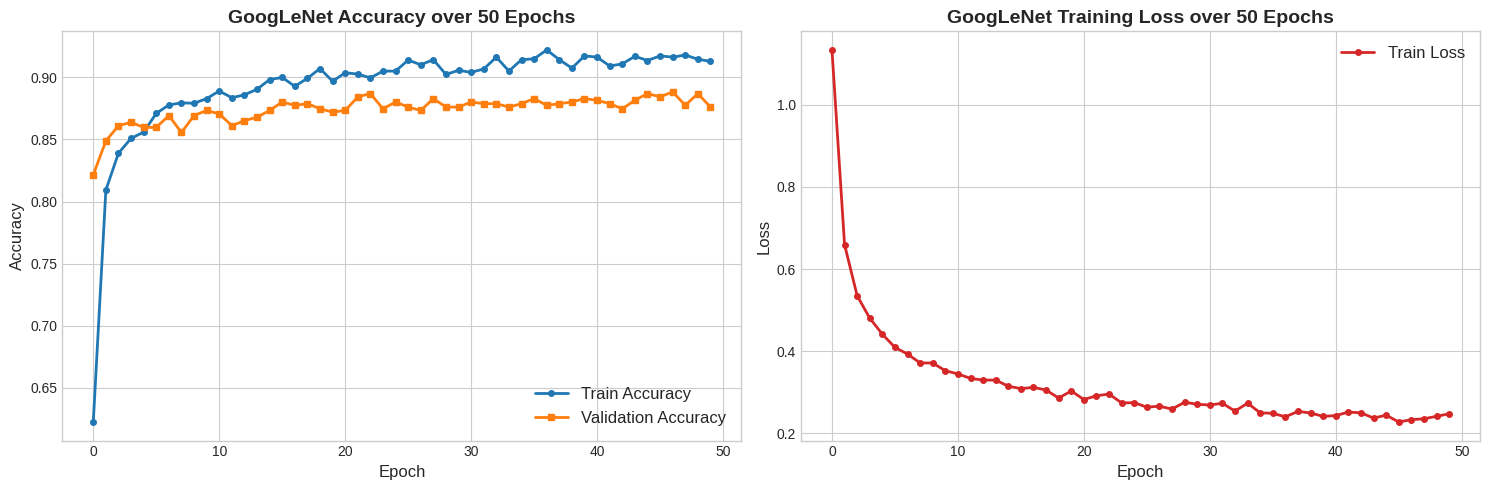

In [22]:
import matplotlib.pyplot as plt

# Use a clean, professional style for the plots
plt.style.use('seaborn-v0_8-whitegrid')

# Create a figure with 1 row and 2 columns
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

axes[0].plot(history['train_acc'], label='Train Accuracy', color='#1f77b4', marker='o', markersize=4, linewidth=2)
axes[0].plot(history['val_acc'], label='Validation Accuracy', color='#ff7f0e', marker='s', markersize=4, linewidth=2)
axes[0].set_title('GoogLeNet Accuracy over 50 Epochs', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Epoch', fontsize=12)
axes[0].set_ylabel('Accuracy', fontsize=12)
axes[0].legend(fontsize=12)

axes[1].plot(history['train_loss'], label='Train Loss', color='#d62728', marker='o', markersize=4, linewidth=2)
axes[1].set_title('GoogLeNet Training Loss over 50 Epochs', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Epoch', fontsize=12)
axes[1].set_ylabel('Loss', fontsize=12)
axes[1].legend(fontsize=12)

# Ensure the plots don't overlap
plt.tight_layout()
plt.show()

In [23]:
# Save the trained weights
save_path = '/kaggle/working/googlenet_5flowers_model.pth'
torch.save(model.state_dict(), save_path)
print(f"GoogLeNet weights successfully saved to {save_path}")

GoogLeNet weights successfully saved to /kaggle/working/googlenet_5flowers_model.pth


In [24]:
import random

# Get the list of flower class names (daisy, dandelion, roses, sunflowers, tulips)
class_names = full_dataset.classes

In [25]:
# 1. Set model to evaluation mode (crucial for GoogLeNet to disable dropout)
model.eval()

DataParallel(
  (module): GoogLeNet(
    (conv1): BasicConv2d(
      (conv): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
      (bn): BatchNorm2d(64, eps=0.001, momentum=0.1, affine=True, track_running_stats=True)
    )
    (maxpool1): MaxPool2d(kernel_size=3, stride=2, padding=0, dilation=1, ceil_mode=True)
    (conv2): BasicConv2d(
      (conv): Conv2d(64, 64, kernel_size=(1, 1), stride=(1, 1), bias=False)
      (bn): BatchNorm2d(64, eps=0.001, momentum=0.1, affine=True, track_running_stats=True)
    )
    (conv3): BasicConv2d(
      (conv): Conv2d(64, 192, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn): BatchNorm2d(192, eps=0.001, momentum=0.1, affine=True, track_running_stats=True)
    )
    (maxpool2): MaxPool2d(kernel_size=3, stride=2, padding=0, dilation=1, ceil_mode=True)
    (inception3a): Inception(
      (branch1): BasicConv2d(
        (conv): Conv2d(192, 64, kernel_size=(1, 1), stride=(1, 1), bias=False)
        (bn

In [26]:
# 2. Select a random image from the validation dataset
random_idx = random.randint(0, len(val_dataset) - 1)
image_tensor, actual_label_idx = val_dataset[random_idx]

In [27]:
# 3. Add a batch dimension: (C, H, W) becomes (1, C, H, W) and move to GPU
image_batch = image_tensor.unsqueeze(0).to(device)

In [28]:
# 4. Perform inference without tracking gradients
with torch.no_grad():
    output = model(image_batch)
    # Get the index of the highest predicted probability
    _, predicted_idx = torch.max(output, 1)

In [29]:
# Extract the string names for the labels
actual_flower = class_names[actual_label_idx]
predicted_flower = class_names[predicted_idx.item()]

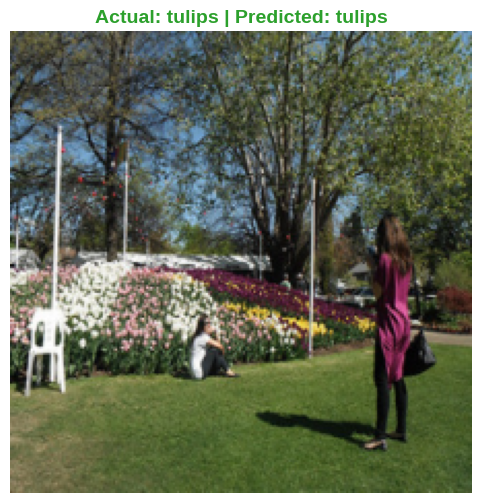

In [30]:
# 5. Un-normalize the image so it displays correctly
image_display = image_tensor.permute(1, 2, 0).cpu().numpy()
mean = [0.485, 0.456, 0.406]
std = [0.229, 0.224, 0.225]
image_display = std * image_display + mean
image_display = image_display.clip(0, 1) # Ensure pixel values remain valid

# 6. Plot the image and the prediction
plt.figure(figsize=(6, 6))
plt.imshow(image_display)

# Color the title green if the prediction is correct, red if incorrect
title_color = "#2ca02c" if actual_flower == predicted_flower else "#d62728"
plt.title(f"Actual: {actual_flower} | Predicted: {predicted_flower}", color=title_color, fontsize=14, fontweight='bold')
plt.axis('off')
plt.show()